In [1]:
import pandas as pd

import os
data_path = os.path.join('..','data','raw')

import matplotlib.pyplot as plt

In [2]:

customers= pd.read_csv(f"{data_path}/customers.csv")
orders = pd.read_csv(f"{data_path}/orders.csv")
sellers = pd.read_csv(f"{data_path}/sellers.csv")
geolocation = pd.read_csv(f"{data_path}/geolocation.csv")


In [3]:
customers.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES


In [4]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05


In [5]:
geolocation.head(3)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.551427,-46.634074,sao paulo,SP
1,1001,-23.551337,-46.634027,sao paulo,SP
2,1001,-23.550642,-46.634410,sao paulo,SP


In [6]:
customer_info_with_address = pd.merge(customers,geolocation,left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix',how='left')

In [33]:
customer_info_with_address.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,6273.0,-23.508027,-46.763820,osasco,SP
1,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,6273.0,-23.507990,-46.764155,osasco,SP
2,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,6273.0,-23.506565,-46.765669,osasco,SP
3,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,6273.0,-23.505767,-46.766667,osasco,SP
4,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,6273.0,-23.505024,-46.767180,osasco,SP


In [7]:
order_customer = orders.merge(right=customer_info_with_address,left_on='customer_id',right_on='customer_id',how='left')

In [8]:
order_customer.head()
order_customer_location =  order_customer.loc[order_customer['order_status'] == 'delivered', ['order_id','customer_id','customer_unique_id','customer_zip_code_prefix','geolocation_lat','geolocation_lng']]

In [9]:
sellers.head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,9080,santo andre,SP
1,001cca7ae9ae17fb1caed9dfb1094831,29156,cariacica,ES
2,001e6ad469a905060d959994f1b41e4f,24754,sao goncalo,RJ


In [10]:
order_items = pd.read_csv(f'{data_path}/order_items.csv')
order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [11]:
df = sellers.merge(left_on='seller_zip_code_prefix',right_on='geolocation_zip_code_prefix',right =geolocation, how='left')
seller_coordinates = df[['seller_id','seller_zip_code_prefix','geolocation_lat','geolocation_lng']]
seller_coordinates


,seller_id,seller_zip_code_prefix,geolocation_lat,geolocation_lng
0,0015a82c2db000af6aaaf3ae2ecb0532,9080,-23.655752,-46.535595
1,0015a82c2db000af6aaaf3ae2ecb0532,9080,-23.654907,-46.536248
2,0015a82c2db000af6aaaf3ae2ecb0532,9080,-23.654658,-46.534755
3,0015a82c2db000af6aaaf3ae2ecb0532,9080,-23.654613,-46.534664
4,0015a82c2db000af6aaaf3ae2ecb0532,9080,-23.654288,-46.534077
...,...,...,...,...
303887,ffff564a4f9085cd26170f4732393726,13070,-22.879047,-47.074180
303888,ffff564a4f9085cd26170f4732393726,13070,-22.878783,-47.074466
303889,ffff564a4f9085cd26170f4732393726,13070,-22.877980,-47.074990
303890,ffff564a4f9085cd26170f4732393726,13070,-22.857362,-47.150361


In [12]:
order_item_with_seller_coordinates = order_items.merge(right=seller_coordinates, on='seller_id')
order_item_with_seller_coordinates = order_item_with_seller_coordinates[['order_id' ,'seller_id' ,'geolocation_lat','geolocation_lng' ]]
order_item_with_seller_coordinates

,order_id,seller_id,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,-22.501227,-44.132443
1,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,-22.501224,-44.132039
2,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,-22.501220,-44.132301
3,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,-22.501090,-44.132543
4,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,-22.500847,-44.124864
...,...,...,...,...
11979874,fffe41c64501cc87c801fd61db3f6244,f7ccf836d21b2fb1de37564105216cc1,-21.742899,-48.838516
11979875,fffe41c64501cc87c801fd61db3f6244,f7ccf836d21b2fb1de37564105216cc1,-21.741482,-48.812926
11979876,fffe41c64501cc87c801fd61db3f6244,f7ccf836d21b2fb1de37564105216cc1,-21.741095,-48.838686
11979877,fffe41c64501cc87c801fd61db3f6244,f7ccf836d21b2fb1de37564105216cc1,-21.738057,-48.823753


In [13]:
# Rename the latitute adn longitute with respective their user.
order_customer_location = order_customer_location.rename(columns={'geolocation_lat':'customer_geolocation_lat','geolocation_lng':'customer_geolocation_lng'})
order_item_with_seller_coordinates = order_item_with_seller_coordinates.rename(columns={'geolocation_lat':'seller_geolocation_lat','geolocation_lng':'seller_geolocation_lng'})


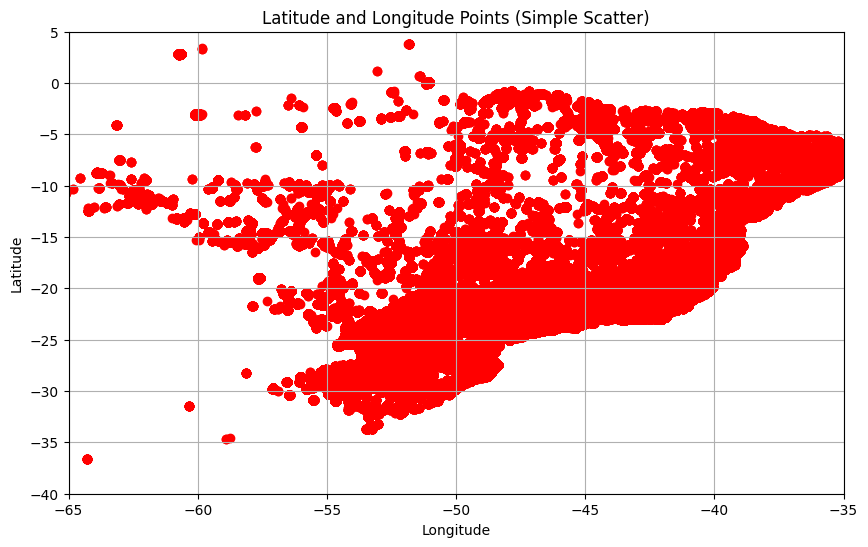

In [36]:
data = customer_info_with_address
plt.figure(figsize=(10, 6))
# Note: Convention for plotting on a flat plane is typically x=longitude, y=latitude
plt.scatter(data['geolocation_lng'], data['geolocation_lat'], color='red', marker='o')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Customer, Latitude and Longitude Points (Simple Scatter)")
plt.grid(True)
plt.xlim(-65,-35)
plt.ylim(-40,5)
plt.show()

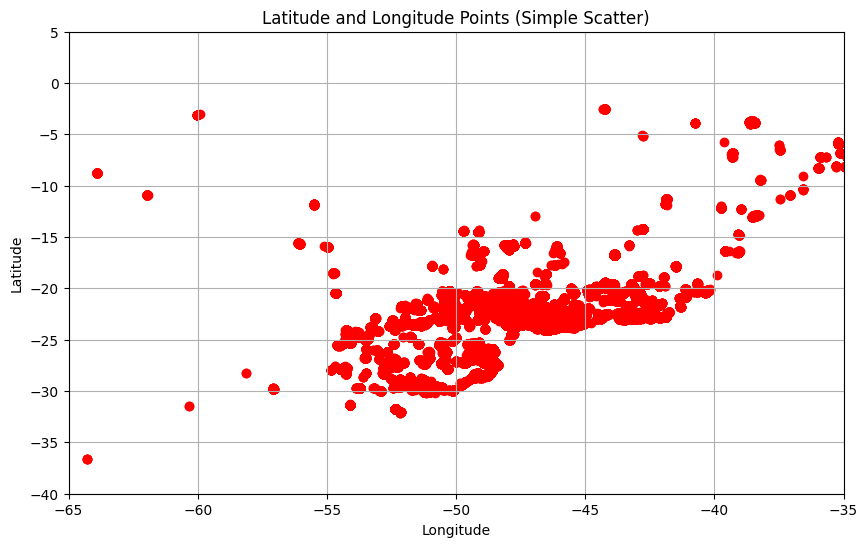

In [37]:
data =seller_coordinates
plt.figure(figsize=(10, 6))
# Note: Convention for plotting on a flat plane is typically x=longitude, y=latitude
plt.scatter(data['geolocation_lng'], data['geolocation_lat'], color='red', marker='o')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Seller, Latitude and Longitude Points (Simple Scatter)")
plt.grid(True)
plt.xlim(-65,-35)
plt.ylim(-40,5)
plt.show()